<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/5%20Modeling/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict, cross_val_score

from sklearn.metrics import mean_absolute_error, r2_score, get_scorer_names, pairwise, confusion_matrix, accuracy_score

Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df

,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0

In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df

,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,...,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Initialize

In [7]:
knc = KNeighborsClassifier(metric='euclidean', n_neighbors=51, weights='distance')
lor = LogisticRegression(C=0.5, penalty='l1', solver='liblinear')
svc = SVC(C=2**10, gamma=0.015625, kernel='rbf')
dtc = DecisionTreeClassifier(criterion='gini', max_depth=14, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
rfc = RandomForestClassifier(criterion='gini', max_depth=11, min_samples_leaf=1, min_samples_split=2, n_estimators=5, random_state=2)
ada = AdaBoostClassifier(learning_rate=1, n_estimators=15)
xgb = XGBClassifier(learning_rate=1, n_estimators=10)

kf = KFold(n_splits=5, shuffle=False)

Modeling

In [8]:
kf_knc = cross_val_score(knc, X, y01, cv=kf, scoring='accuracy')
print(kf_knc.mean(), kf_knc.std())

0.902942439862543 0.06534069960291367


In [9]:
kf_lor = cross_val_score(lor, X, y01, cv=kf, scoring='accuracy')
print(kf_lor.mean(), kf_lor.std())

0.8532860824742269 0.05923477219332033


In [10]:
kf_svc = cross_val_score(svc, X, y01, cv=kf, scoring='accuracy')
print(kf_svc.mean(), kf_svc.std())

0.8885524054982818 0.11756176004218202


In [11]:
kf_dtc = cross_val_score(dtc, X, y01, cv=kf, scoring='accuracy')
print(kf_dtc.mean(), kf_dtc.std())

0.9091280068728522 0.06877791663621698


In [12]:
kf_rfc = cross_val_score(rfc, X, y01, cv=kf, scoring='accuracy')
print(kf_rfc.mean(), kf_rfc.std())

0.8967568728522336 0.08085613127501134


In [13]:
kf_ada = cross_val_score(ada, X, y01, cv=kf, scoring='accuracy')
print(kf_ada.mean(), kf_ada.std())

0.8636168384879724 0.05397384203307856


In [14]:
kf_xgb = cross_val_score(xgb, X, y01, cv=kf, scoring='accuracy')
print(kf_xgb.mean(), kf_xgb.std())

0.8988187285223368 0.06493960341254196


Visualize

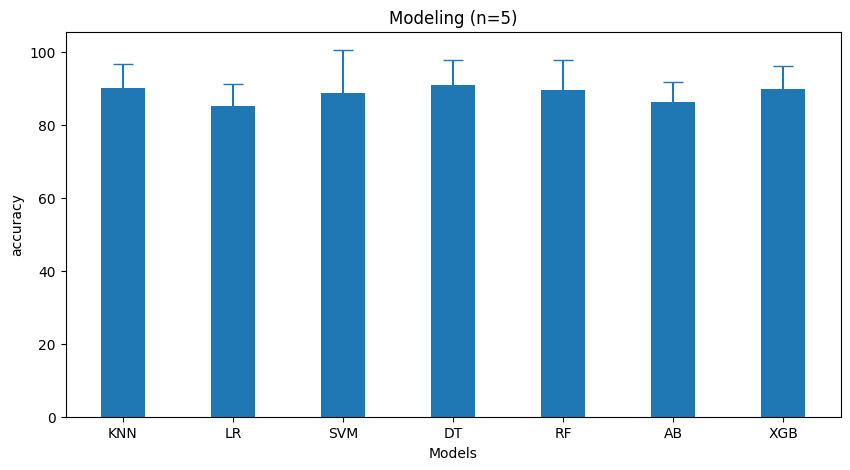

In [15]:
bar = {'KNN':90.29, 'LR':85.33, 'SVM':88.86, 'DT':90.91, 'RF':89.68, 'AB':86.36, 'XGB':89.88}
error = np.array([6.53, 5.92, 11.76, 6.88, 8.09, 5.40, 6.49])
courses = list(bar.keys())
values = list(bar.values())

fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(courses, values, width = 0.4, color=plt.cm.tab10.colors[0])
plt.errorbar(courses, values, error, capsize=7, linestyle='None', ecolor=plt.cm.tab10.colors[0])

plt.xlabel("Models")
plt.ylabel("accuracy")
plt.title('Modeling (n=5)')

plt.show()